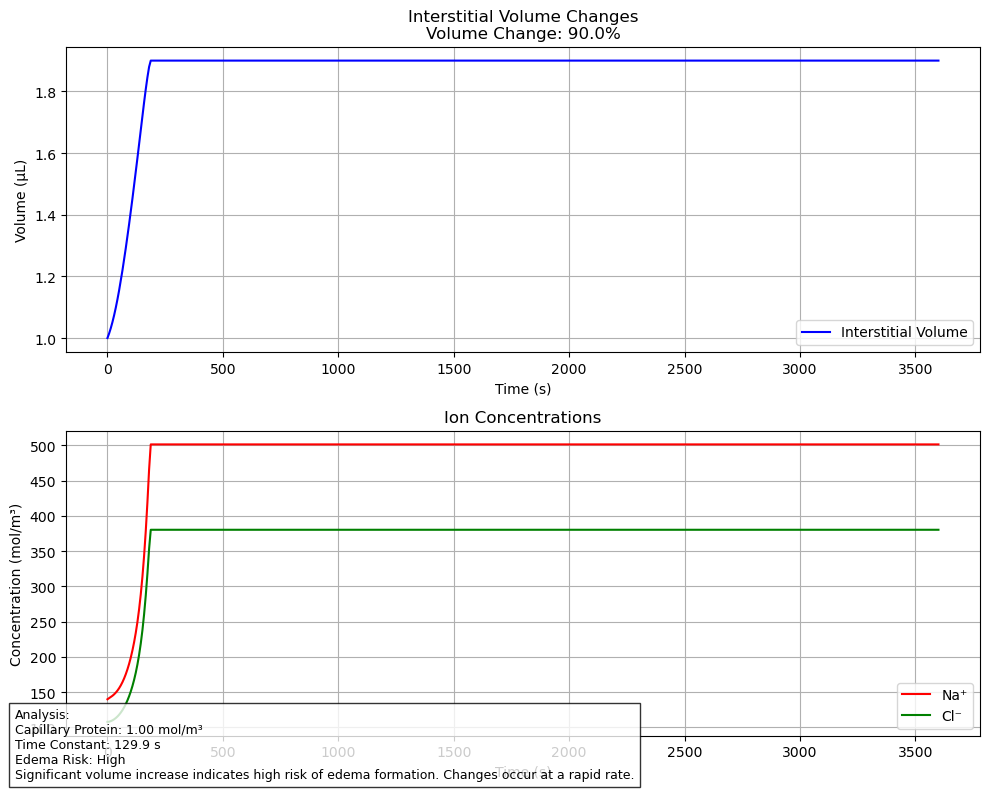

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display, clear_output
import ipywidgets as widgets

class DonnanSimulation:
    def __init__(self):
        # System constants remain the same
        self.R = 8.314
        self.T = 310.15
        self.F = 96485
        self.P_w = 1e-9
        self.A = 1e-4
        
        # Initial volumes
        self.V_i = 1.0e-6
        self.V_c = 1.2e-6
        self.total_volume = self.V_i + self.V_c
        
        # Initial ion concentrations (mol/m³)
        self.Na_c = 145
        self.Na_i = 140
        self.Cl_c = 110
        self.Cl_i = 108
        
        # Create the figure once
        self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=(10, 8))
        
    def calculate_osmotic_pressure(self, c1, c2):
        return self.R * self.T * (c1 - c2)

    def calculate_membrane_potential(self, Na_i, Na_c, Cl_i, Cl_c):
        return (self.R * self.T / self.F) * np.log((Na_c + Cl_i) / (Na_i + Cl_c))

    def assess_edema_risk(self, volume_change, time_constant):
        """Assess the risk of edema based on simulation results"""
        if volume_change > 20:
            risk = "High"
            explanation = "Significant volume increase indicates high risk of edema formation"
        elif volume_change > 10:
            risk = "Moderate"
            explanation = "Volume increase suggests potential for edema development"
        elif volume_change > 5:
            risk = "Low"
            explanation = "Minor volume changes indicate low risk of edema"
        else:
            risk = "Minimal"
            explanation = "Volume changes within normal physiological range"
            
        if time_constant < 600:  # 10 minutes
            speed = "rapid"
        else:
            speed = "gradual"
            
        return risk, f"{explanation}. Changes occur at a {speed} rate."

    def system_dynamics(self, t, state, P_c, P_i):
        V_i, Na_i, Cl_i = state
        
        # Calculate capillary values
        V_c = self.total_volume - V_i
        
        # Volume bounds check
        if V_i <= 0.1e-6 or V_i >= 1.9e-6:
            return [0, 0, 0]
            
        Na_c = self.Na_c * self.V_c / V_c
        Cl_c = self.Cl_c * self.V_c / V_c
        
        # Calculate driving forces
        pi_protein = self.calculate_osmotic_pressure(P_c, P_i)
        pi_ions = self.calculate_osmotic_pressure(Na_c + Cl_c, Na_i + Cl_i)
        
        # Volume flux with nonlinear dampening
        J_v = self.P_w * self.A * (pi_protein + pi_ions) * (1 - abs(V_i - self.V_i) / self.V_i)
        
        # Ion fluxes
        dV_i_dt = J_v
        dNa_i_dt = -Na_i * J_v / V_i + 0.1 * (Na_c - Na_i)
        dCl_i_dt = -Cl_i * J_v / V_i + 0.1 * (Cl_c - Cl_i)
        
        return [dV_i_dt, dNa_i_dt, dCl_i_dt]

    def simulate(self, P_c, P_i, t_span=3600):
        y0 = [self.V_i, self.Na_i, self.Cl_i]
        t = np.linspace(0, t_span, 500)
        
        solution = solve_ivp(
            lambda t, y: self.system_dynamics(t, y, P_c, P_i),
            [0, t_span],
            y0,
            t_eval=t,
            method='RK45',
            rtol=1e-6,
            atol=1e-8
        )
        
        return solution.t, solution.y[0], solution.y[1], solution.y[2]

    def update_plots(self, P_c, P_i=0.6):
        """Update plots based on protein concentrations"""
        # Clear previous plots
        self.ax1.clear()
        self.ax2.clear()
        
        # Run simulation
        t, V_i, Na_i, Cl_i = self.simulate(P_c, P_i)
        
        # Calculate metrics
        volume_change_percent = ((V_i[-1] - V_i[0]) / V_i[0]) * 100
        target_volume = V_i[0] + 0.63 * (V_i[-1] - V_i[0])
        time_constant = t[np.argmin(np.abs(V_i - target_volume))]
        
        # Get edema risk assessment
        risk, explanation = self.assess_edema_risk(volume_change_percent, time_constant)
        
        # Plot volume changes
        self.ax1.plot(t, V_i * 1e6, 'b-', label='Interstitial Volume')
        self.ax1.set_xlabel('Time (s)')
        self.ax1.set_ylabel('Volume (µL)')
        self.ax1.set_title(f'Interstitial Volume Changes\nVolume Change: {volume_change_percent:.1f}%')
        self.ax1.grid(True)
        self.ax1.legend()
        
        # Plot ion concentrations
        self.ax2.plot(t, Na_i, 'r-', label='Na⁺')
        self.ax2.plot(t, Cl_i, 'g-', label='Cl⁻')
        self.ax2.set_xlabel('Time (s)')
        self.ax2.set_ylabel('Concentration (mol/m³)')
        self.ax2.set_title('Ion Concentrations')
        self.ax2.grid(True)
        self.ax2.legend()
        
        # Add analysis text
        plt.figtext(0.02, 0.02, 
                   f'Analysis:\n' +
                   f'Capillary Protein: {P_c:.2f} mol/m³\n' +
                   f'Time Constant: {time_constant:.1f} s\n' +
                   f'Edema Risk: {risk}\n' +
                   f'{explanation}',
                   fontsize=9, bbox=dict(facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        display(self.fig)
        
def create_interactive_simulation():
    """Create and display interactive simulation widget"""
    sim = DonnanSimulation()
    
    # Create slider for protein concentration
    protein_slider = widgets.FloatSlider(
        value=1.0,
        min=0.5,
        max=2.0,
        step=0.1,
        description='Capillary Protein (mol/m³):',
        continuous_update=False,  # Only update on release
        style={'description_width': 'initial'},
        layout={'width': '50%'}
    )
    
    # Create output widget for plots
    output = widgets.Output()
    
    # Define update function
    def update(change):
        with output:
            clear_output(wait=True)
            sim.update_plots(change['new'])
    
    # Register callback
    protein_slider.observe(update, names='value')
    
    # Display initial plot
    with output:
        sim.update_plots(protein_slider.value)
    
    # Display widgets
    display(widgets.VBox([protein_slider, output]))

# Create and display the interactive simulation
create_interactive_simulation()